# LLM 기반 추천 시스템 구현

## 1.데이터 전처리
- kaggle에서 제공되는 Movie recommendation data 데이터셋 사용.
- https://www.kaggle.com/datasets/rohan4050/movie-recommendation-data
- 각 영화에 대한 텍스트 설명(평점 및 영화 제목과 같은 정보와 함께)이 포함된 데이터셋을 사용하는 이유는 텍스트의 임베딩을 가져오기 위함.

In [1]:
import pandas as pd

md = pd. read_csv('../data1/movies_metadata.csv')
md.head()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10972\3340424614.py:3: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  md = pd. read_csv('../data1/movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [2]:
md['genres'][0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [3]:
import ast

# 문자열로 표현된 딕셔너리를 실제 딕셔너리로 변환
md['genres'] = md['genres'].apply(ast.literal_eval)

# 'genres' 열 변환
md['genres'] = md['genres'].apply(lambda x: [genre['name'] for genre in x])


md.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[Romance, Comedy]",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[Comedy, Drama, Romance]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


- 투표 수에 대한 가중치를 부여한 vote_agerage 및  vote_count 열을 단일 열로 병함.
- 또한 행을 투표 수의 95 백분위수로 제한하여 왜곡된 결과를 방지하기 위해 최소 투표 수를 제거할 수 있게 함.

In [4]:
# 가중 평점 계산 (IMDb 공식)
def calculate_weighted_rate(vote_average, vote_count, min_vote_count=10):
    return (vote_count / (vote_count + min_vote_count)) * vote_average + (min_vote_count / (vote_count + min_vote_count)) * 5.0

In [5]:
# 왜곡된 결과를 방지하기 위한 최소 투표 수
vote_counts = md[md['vote_count'].notnull()]['vote_count'].astype('int')
min_vote_count = vote_counts.quantile(0.95)

In [6]:
# 새로운 'weighted_rate' 열을 만듦
md['weighted_rate'] = md.apply(lambda row: calculate_weighted_rate(row['vote_average'], row['vote_count'], min_vote_count), axis=1)
md.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,weighted_rate
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,7.499658
1,False,NaN,65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,6.610362
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[Romance, Comedy]",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,5.262357
3,False,NaN,16000000,"[Comedy, Drama, Romance]",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,5.079915
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,5.199506


In [7]:
md = md.dropna()

In [8]:
md_final = md[['genres', 'title', 'overview', 'weighted_rate']].reset_index(drop=True)
md_final.head()

,genres,title,overview,weighted_rate
0,"[Adventure, Action, Thriller]",GoldenEye,James Bond must unmask the mysterious head of ...,6.173464
1,[Comedy],Friday,Craig and Smokey are two guys in Los Angeles h...,6.083421
2,"[Horror, Action, Thriller, Crime]",From Dusk Till Dawn,Seth Gecko and his younger brother Richard are...,6.503176
3,[Comedy],Blue in the Face,"Auggie runs a small tobacco shop in Brooklyn, ...",5.109091
4,"[Action, Adventure, Science Fiction, Family, F...",Mighty Morphin Power Rangers: The Movie,Power up with six incredible teens who out-man...,5.052129


In [9]:
md.info()

<class 'pandas.DataFrame'>
Index: 693 entries, 9 to 45029
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  693 non-null    str    
 1   belongs_to_collection  693 non-null    str    
 2   budget                 693 non-null    str    
 3   genres                 693 non-null    object 
 4   homepage               693 non-null    str    
 5   id                     693 non-null    str    
 6   imdb_id                693 non-null    str    
 7   original_language      693 non-null    str    
 8   original_title         693 non-null    str    
 9   overview               693 non-null    str    
 10  popularity             693 non-null    object 
 11  poster_path            693 non-null    str    
 12  production_companies   693 non-null    str    
 13  production_countries   693 non-null    str    
 14  release_date           693 non-null    str    
 15  revenue             

- 우리가 관심을 두는 열
    - Genres : 영화에 적용 가능한 장르 목록
    - Title : 영화 제목
    - Overview : 줄거리에 대한 텍스트 설명
    - Vote_average : 주어진 영화에 대한 1부터 10까지의 평점
    - Vote_count : 주어진 영화에 대한 투표 수

In [10]:
md[['genres', 'title', 'overview', 'vote_average', 'vote_count']].info()

<class 'pandas.DataFrame'>
Index: 693 entries, 9 to 45029
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genres        693 non-null    object 
 1   title         693 non-null    str    
 2   overview      693 non-null    str    
 3   vote_average  693 non-null    float64
 4   vote_count    693 non-null    float64
dtypes: float64(2), object(1), str(2)
memory usage: 270.9+ KB


In [11]:
md_final = md[['genres', 'title', 'overview', 'weighted_rate']].reset_index(drop=True)
md_final.head()

,genres,title,overview,weighted_rate
0,"[Adventure, Action, Thriller]",GoldenEye,James Bond must unmask the mysterious head of ...,6.173464
1,[Comedy],Friday,Craig and Smokey are two guys in Los Angeles h...,6.083421
2,"[Horror, Action, Thriller, Crime]",From Dusk Till Dawn,Seth Gecko and his younger brother Richard are...,6.503176
3,[Comedy],Blue in the Face,"Auggie runs a small tobacco shop in Brooklyn, ...",5.109091
4,"[Action, Adventure, Science Fiction, Family, F...",Mighty Morphin Power Rangers: The Movie,Power up with six incredible teens who out-man...,5.052129


- LLM에 문맥으로 제공할 모든 요소(영화 제목, 개요, 장르, 등급)를 병합할 combined_info라는 새 열을 만듦.

In [12]:
md_final['combined_info'] = md_final.apply(lambda row: f"Title: {row['title']}. Overview: {row['overview']} Genres: {', '.join(row['genres'])}. Rating: {row['weighted_rate']}", axis=1)
md_final['combined_info'][9]

'Title: Jurassic Park. Overview: A wealthy entrepreneur secretly creates a theme park featuring living dinosaurs drawn from prehistoric DNA. Before opening day, he invites a team of experts and his two eager grandchildren to experience the park and help calm anxious investors. However, the park is anything but amusing as the security systems go off-line and the dinosaurs escape. Genres: Adventure, Science Fiction. Rating: 7.39064935064935'

## 2.임베딩
- `cl100k_base`는 OpenAI의 임베딩 API에서 사용하는 토크나이저의 이름.
- 토크나이저는 텍스트 문자열을 토큰이라는 단위로 분할한 다음 신경망에서 처리할 수 있도록 하는 도구.
- 토크나이저마다 텍스트를 분할하는 방법과 사용할 토큰에 대한 규칙과 어휘가 다름.
- `cl100k_base` 토크나이저는 대규모 텍스트 말뭉치에서 하위 단어 단위의 어휘를 학습하는 바이트 페어 인코딩(BPE) 알고리즘을 기반으로 함.
- 여러 언어와 도메인의 텍스트를 처리할 수 있으며 입력당 최대 8,191개의 토큰을 인코더로 인코딩할 수 있음.

In [13]:
import tiktoken
from openai import OpenAI
from dotenv import load_dotenv
import os 

load_dotenv()

api_key = os.getenv('OPENAI_API_KEY')

In [14]:
# https://developers.openai.com/cookbook/examples/how_to_count_tokens_with_tiktoken?utm_source=chatgpt.com
embedding_model='text-embedding-3-small'
embedding_encoding = 'cl100k_base'
max_tokens = 8000   # 최대 8191개의 토큰을 인코딩할 수 있음

client = OpenAI(api_key=api_key)

encoding = tiktoken.get_encoding(embedding_encoding)

In [15]:
def get_embedding(text, engine=embedding_model):
   text = text.replace("\n", " ")
   return client.embeddings.create(input = [text], model=engine).data[0].embedding

# 임베딩하기에 너무 긴 리뷰는 제외
md_final["n_tokens"] = md_final.combined_info.apply(lambda x: len(encoding.encode(x)))
md_final = md_final[md_final.n_tokens <= max_tokens]
len(md_final)

693

In [16]:
md_final.head()

,genres,title,overview,weighted_rate,combined_info,n_tokens
0,"[Adventure, Action, Thriller]",GoldenEye,James Bond must unmask the mysterious head of ...,6.173464,Title: GoldenEye. Overview: James Bond must un...,59
1,[Comedy],Friday,Craig and Smokey are two guys in Los Angeles h...,6.083421,Title: Friday. Overview: Craig and Smokey are ...,52
2,"[Horror, Action, Thriller, Crime]",From Dusk Till Dawn,Seth Gecko and his younger brother Richard are...,6.503176,Title: From Dusk Till Dawn. Overview: Seth Gec...,105
3,[Comedy],Blue in the Face,"Auggie runs a small tobacco shop in Brooklyn, ...",5.109091,Title: Blue in the Face. Overview: Auggie runs...,87
4,"[Action, Adventure, Science Fiction, Family, F...",Mighty Morphin Power Rangers: The Movie,Power up with six incredible teens who out-man...,5.052129,Title: Mighty Morphin Power Rangers: The Movie...,89


- `text-embedding-ada-002`로 텍스트를 임베딩

In [17]:
md_final["embedding"] = md_final.overview.apply(lambda x: get_embedding(x, engine=embedding_model))
md_final.head()

,genres,title,overview,weighted_rate,combined_info,n_tokens,embedding
0,"[Adventure, Action, Thriller]",GoldenEye,James Bond must unmask the mysterious head of ...,6.173464,Title: GoldenEye. Overview: James Bond must un...,59,"[0.01366424560546875, 0.0601806640625, 0.04415..."
1,[Comedy],Friday,Craig and Smokey are two guys in Los Angeles h...,6.083421,Title: Friday. Overview: Craig and Smokey are ...,52,"[-0.00576019287109375, 0.024169921875, -0.0409..."
2,"[Horror, Action, Thriller, Crime]",From Dusk Till Dawn,Seth Gecko and his younger brother Richard are...,6.503176,Title: From Dusk Till Dawn. Overview: Seth Gec...,105,"[0.03924560546875, 0.05523681640625, 0.0242462..."
3,[Comedy],Blue in the Face,"Auggie runs a small tobacco shop in Brooklyn, ...",5.109091,Title: Blue in the Face. Overview: Auggie runs...,87,"[0.004238128662109375, -0.0211944580078125, -0..."
4,"[Action, Adventure, Science Fiction, Family, F...",Mighty Morphin Power Rangers: The Movie,Power up with six incredible teens who out-man...,5.052129,Title: Mighty Morphin Power Rangers: The Movie...,89,"[1.3232231140136719e-05, 0.04931640625, -0.027..."


In [18]:
md_final.rename(columns = {'embedding': 'vector'}, inplace = True)
md_final.rename(columns = {'combined_info': 'text'}, inplace = True)
md_final.to_pickle('movies.pkl')

## 3.LLM 작업 시작
- 벡터DB에 저장
- 영구저장소로 구축된 벡터 검색용 오픈소스 데이터베이스인 LanceDB 활용하여 검색, 필터링 및 임베딩 관리를 크게 간소화하고 랭체인과의 기본 통합을 제공하고자 함

- LanceDB : '벡터 데이터베이스(Vector Database)’의 일종으로, AI가 데이터를 빠르게 찾고 비교할 수 있게 도와주는 데이터 저장소
- 특징 : 속도가 빠르고, 간단한 RAG 및 실험에 많이 사용. 로컬에서 쓸 수 있는 가볍고 빠른 벡터DB

In [22]:
from langchain_community.vectorstores import LanceDB

In [23]:
md = pd.read_pickle("movies.pkl")
md.head(2)

,genres,title,overview,weighted_rate,text,n_tokens,vector
0,"[Adventure, Action, Thriller]",GoldenEye,James Bond must unmask the mysterious head of ...,6.173464,Title: GoldenEye. Overview: James Bond must un...,59,"[0.01366424560546875, 0.0601806640625, 0.04415..."
1,[Comedy],Friday,Craig and Smokey are two guys in Los Angeles h...,6.083421,Title: Friday. Overview: Craig and Smokey are ...,52,"[-0.00576019287109375, 0.024169921875, -0.0409..."


In [19]:
# 검색 시 KeyError: 'Field "metadata" does not exist in schema' 에러를 피하기 위해 metadata 필드를 추가
md['metadata'] = md.apply(lambda row: {'genres': row['genres'], 'title': row['title'], 'overview': row['overview'], 'weighted_rate': row['weighted_rate']}, axis=1)

In [24]:
md['text'][0]

'Title: GoldenEye. Overview: James Bond must unmask the mysterious head of the Janus Syndicate and prevent the leader from utilizing the GoldenEye weapons system to inflict devastating revenge on Britain. Genres: Adventure, Action, Thriller. Rating: 6.173464373464373'

In [27]:
import lancedb

root = r'C:\DB\sample-lancedb'
os.makedirs(root, exist_ok=True)

db = lancedb.connect(root)
table = db.create_table('movies', md)

In [38]:
# 현재 DB에 존재하는 테이블(=collection) 목록 출력
print(db.table_names())

['movies']


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10972\779614060.py:2: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  print(db.table_names())


In [39]:
table = db.open_table("movies")
print(table)

LanceTable(name='movies', _conn=LanceDBConnection(uri='C:\\DB\\sample-lancedb'))


In [43]:
# 첫 5개 행 미리보기
print(table.to_pandas().head())

# 스키마(컬럼 정보) 확인
print(table.schema)

                                              genres  \
0                      [Adventure, Action, Thriller]   
1                                           [Comedy]   
2                  [Horror, Action, Thriller, Crime]   
3                                           [Comedy]   
4  [Action, Adventure, Science Fiction, Family, F...   

                                     title  \
0                                GoldenEye   
1                                   Friday   
2                      From Dusk Till Dawn   
3                         Blue in the Face   
4  Mighty Morphin Power Rangers: The Movie   

                                            overview  weighted_rate  \
0  James Bond must unmask the mysterious head of ...       6.173464   
1  Craig and Smokey are two guys in Los Angeles h...       6.083421   
2  Seth Gecko and his younger brother Richard are...       6.503176   
3  Auggie runs a small tobacco shop in Brooklyn, ...       5.109091   
4  Power up with six incredible

### 3.1. 콜드 스타트 시나리오에서 QA 추첫 챗봇 구축

- 콜드 스타트(Cold Start)란?
    - 추천 시스템이 **충분한 데이터가 없어서 정확한 추천을 하지 못하는 상황**을 말한다.  
    - 즉, "누가 무엇을 좋아하는지" 알 수 없을 때 발생하는 **데이터 부족 문제**.

- 왜 중요한가?
    - 추천 시스템은 **데이터 기반 학습** 으로 작동한다.  
    - 하지만 **데이터가 부족한 초기에는 모델이 학습할 수 없음.**  
    - 결과적으로 “아무것도 추천하지 못하거나 부정확한 추천”을 하게 된다.



- 발생 유형

| 유형 | 설명 | 예시 |
|------|------|------|
| **사용자 콜드 스타트 (User Cold Start)** | 새로운 사용자가 들어왔지만 아직 행동 데이터(클릭, 구매, 평가 등)가 없음 | 새로 가입한 넷플릭스 사용자가 아무 영화도 안 봄 |
| **아이템 콜드 스타트 (Item Cold Start)** | 새로 등록된 상품/영화 등에 대한 사용자 피드백이 없음 | 새로 올라온 유튜브 영상이 조회수 0인 상태 |
| **시스템 콜드 스타트 (System Cold Start)** | 서비스 초기라 사용자/아이템 모두 데이터가 거의 없음 | 런칭 초기의 신규 서비스 |

- 해결 전략

| 접근 방법 | 설명 | 예시 |
|------------|------|------|
| **콘텐츠 기반 필터링** | 아이템의 속성(키워드, 카테고리 등)을 이용해 추천 | “SF 장르 영화를 좋아하면 비슷한 SF 영화를 추천” |
| **초기 설문 (Onboarding)** | 사용자의 선호를 직접 입력받아 초기 데이터 확보 | “좋아하는 장르 3개를 선택하세요 🎬” |
| **인기 기반 추천 (Popularity-based)** | 모든 사용자에게 인기 있는 아이템을 우선 추천 | “지금 인기 급상승 영화 TOP 10” |
| **하이브리드 방식** | 콘텐츠 기반 + 협업 필터링을 조합 | “처음엔 콘텐츠 기반 → 이후엔 사용자 행동 기반으로 전환” |
| **외부 데이터 활용** | SNS, 검색 기록, 프로필 등 외부 정보로 초기 추정 | “트위터에서 언급한 음악을 기반으로 추천” |

- 콜드 스타트 시나리오에서 추천 시스템의 상위 수준 아키텍처

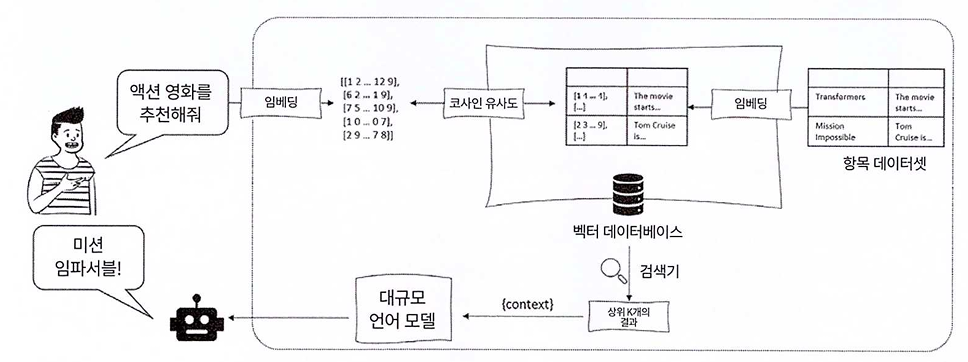

In [48]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import LanceDB
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.language_models import BaseLanguageModel
from types import SimpleNamespace
from typing import Optional, List, Dict, Any

# 이 체인은 사용자의 쿼리에 대해 코사인 유사도를 거리 메트릭으로 사용하여 가장 유사한 상위 K개의 영화를 반환한다는 아이디어.

DEFAULT_RAG_TEMPLATE = """
Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know. Don't try to make up an answer.

{context}

Question: {question}
Helpful Answer:
"""

DEFAULT_RAG_PROMPT = PromptTemplate(
    template=DEFAULT_RAG_TEMPLATE,
    input_variables=["context", "question"]
)

def format_docs(docs: List[Any]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

class SimpleRetrievalQA:
    def __init__(self, llm: BaseLanguageModel, retriever: Any, prompt: Optional[PromptTemplate] = None, return_source_documents: bool = True):
        self.llm = llm
        self.retriever = retriever
        self.prompt = prompt or DEFAULT_RAG_PROMPT
        self.return_source_documents = return_source_documents
        self.answer_chain = self.prompt | self.llm | StrOutputParser()
        self.combine_documents_chain = SimpleNamespace(
            llm_chain=SimpleNamespace(prompt=self.prompt)
        )

    def invoke(self, inputs: Any) -> Dict[str, Any]:
        query = inputs["query"] if isinstance(inputs, dict) else inputs
        docs = self.retriever.invoke(query)
        result = self.answer_chain.invoke({"context": format_docs(docs), "question": query})
        output = {"query": query, "result": result}
        if self.return_source_documents:
            output["source_documents"] = docs
        return output

    def __call__(self, inputs: Any) -> Dict[str, Any]:
        return self.invoke(inputs)

def build_retrieval_qa(llm: BaseLanguageModel, retriever: Any, prompt: Optional[PromptTemplate] = None, return_source_documents: bool = True) -> SimpleRetrievalQA:
    return SimpleRetrievalQA(
        llm=llm,
        retriever=retriever,
        prompt=prompt,
        return_source_documents=return_source_documents
    )

embeddings = OpenAIEmbeddings(model=embedding_model)
docsearch = LanceDB(connection=db, embedding=embeddings, table_name='movies')

query = docs = docsearch.similarity_search(query) docs

In [49]:
query = '''
I'm looking for an animated action movie. What could you suggest to me?
'''

docs = docsearch.similarity_search(query)
docs

[Document(metadata={}, page_content='Title: The Transporter Refueled. Overview: The fast-paced action movie is again set in the criminal underworld in France, where Frank Martin is known as The Transporter, because he is the best driver and mercenary money can buy. In this installment, he meets Anna and they attempt to take down a group of ruthless Russian human traffickers who also have kidnapped Frank’s father. Genres: Thriller, Action, Crime. Rating: 5.170705064548162'),
 Document(metadata={}, page_content="Title: Pacific Rim. Overview: When legions of monstrous creatures, known as Kaiju, started rising from the sea, a war began that would take millions of lives and consume humanity's resources for years on end. To combat the giant Kaiju, a special type of weapon was devised: massive robots, called Jaegers, which are controlled simultaneously by two pilots whose minds are locked in a neural bridge. But even the Jaegers are proving nearly defenseless in the face of the relentless Kai

In [50]:
docs[0].page_content

'Title: The Transporter Refueled. Overview: The fast-paced action movie is again set in the criminal underworld in France, where Frank Martin is known as The Transporter, because he is the best driver and mercenary money can buy. In this installment, he meets Anna and they attempt to take down a group of ruthless Russian human traffickers who also have kidnapped Frank’s father. Genres: Thriller, Action, Crime. Rating: 5.170705064548162'

In [62]:
from langchain_openai import ChatOpenAI

qa = build_retrieval_qa(
    llm=ChatOpenAI(
        model='gpt-4.1-mini',
        temperature=0,
        max_tokens=800
    ),
    retriever=docsearch.as_retriever(),
    return_source_documents=True
)

query = "I'm looking for an action movie. What could you suggest to me?"
result = qa.invoke({"query": query})
result['result']

'Based on the action movies listed, I would suggest **The Raid**. It has a strong action focus with intense thriller elements and a higher rating (6.64) compared to the others. It features an elite SWAT team fighting their way through a dangerous building, promising high-energy and martial arts action. If you prefer something with a mix of crime and thriller, **Hitman** is also a good choice, starring Timothy Olyphant as a skilled assassin.'

In [63]:
result['source_documents']

[Document(metadata={}, page_content='Title: Hitman. Overview: The best-selling videogame, Hitman, roars to life with both barrels blazing in this hardcore action-thriller starring Timothy Olyphant. A genetically engineered assassin with deadly aim, known only as "Agent 47" eliminates strategic targets for a top-secret organization. But when he\'s double-crossed, the hunter becomes the prey as 47 finds himself in a life-or-death game of international intrigue. Genres: Action, Crime, Drama, Thriller. Rating: 5.624152542372881'),
 Document(metadata={}, page_content='Title: The Transporter Refueled. Overview: The fast-paced action movie is again set in the criminal underworld in France, where Frank Martin is known as The Transporter, because he is the best driver and mercenary money can buy. In this installment, he meets Anna and they attempt to take down a group of ruthless Russian human traffickers who also have kidnapped Frank’s father. Genres: Thriller, Action, Crime. Rating: 5.1707050

- 다른 변수들도 활용하도록 하려면 어떻게 해야 할까?

a.필터 방식
 - 이 접근 방식은 사용자에게 응답하기 전에 애플리케이션에서 요구할 수 있는 몇 가지 필터를 검색기에 kwarg로 추가하는 것으로 구성됨.

In [55]:
# df_filtered = md[md['genres'].apply(lambda x: 'Comedy' in x)]
qa = build_retrieval_qa(
    llm=ChatOpenAI(model='gpt-4.1-mini', temperature=0.2, max_tokens=800),
    retriever=docsearch.as_retriever(
        search_kwargs={'filter': "text LIKE '%Comedy%'"}
        ),
        return_source_documents=True)

query = "I'm looking for a movie with animals and an adventurous plot."
result = qa({"query": query})
result

{'query': "I'm looking for a movie with animals and an adventurous plot.",
 'result': 'Based on your interest in a movie with animals and an adventurous plot, here are some great options:\n\n1. **Alpha and Omega 3: The Great Wolf Games** – This animated family adventure features wolves and other forest animals competing in friendly games, with a heartwarming and exciting storyline.\n\n2. **Ice Age** – This animated adventure follows a woolly mammoth, saber-toothed tiger, and giant sloth as they embark on a journey to return an orphaned infant to its human family, facing various challenges along the way.\n\n3. **The Curse of the Were-Rabbit** – This animated comedy-adventure involves a clever inventor and his dog working to solve a mystery involving a monster threatening a vegetable-growing contest.\n\nAll three movies feature animals and adventurous plots, so you might enjoy any of them depending on your preferred style and tone.',
 'source_documents': [Document(metadata={}, page_conte

In [56]:
result['result']

'Based on your interest in a movie with animals and an adventurous plot, here are some great options:\n\n1. **Alpha and Omega 3: The Great Wolf Games** – This animated family adventure features wolves and other forest animals competing in friendly games, with a heartwarming and exciting storyline.\n\n2. **Ice Age** – This animated adventure follows a woolly mammoth, saber-toothed tiger, and giant sloth as they embark on a journey to return an orphaned infant to its human family, facing various challenges along the way.\n\n3. **The Curse of the Were-Rabbit** – This animated comedy-adventure involves a clever inventor and his dog working to solve a mystery involving a monster threatening a vegetable-growing contest.\n\nAll three movies feature animals and adventurous plots, so you might enjoy any of them depending on your preferred style and tone.'

In [64]:
# 평점 등급이 6.5 이상인 결과만 필터링
qa = build_retrieval_qa(
    llm=ChatOpenAI(model='gpt-4.1-mini', temperature=0.2, max_tokens=800),
        retriever=docsearch.as_retriever(
            search_kwargs={'filter': 'weighted_rate > 6.5'}
            ),
    return_source_documents=True) # 문서의 출처도 검색

query = "I'm looking for a movie with animals and an adventurous plot."
result = qa({"query": query})
result

{'query': "I'm looking for a movie with animals and an adventurous plot.",
 'result': 'A good movie that fits your description is "Ice Age." It features a group of prehistoric animals—a woolly mammoth, a saber-toothed tiger, and a giant sloth—who embark on an adventurous journey to return an orphaned human infant to its family. The film combines elements of animation, comedy, family, and adventure.',
 'source_documents': [Document(metadata={}, page_content='Title: Ice Age. Overview: With the impending ice age almost upon them, a mismatched trio of prehistoric critters – Manny the woolly mammoth, Diego the saber-toothed tiger and Sid the giant sloth – find an orphaned infant and decide to return it to its human parents. Along the way, the unlikely allies become friends but, when enemies attack, their quest takes on far nobler aims. Genres: Animation, Comedy, Family, Adventure. Rating: 6.892297174111213')]}

In [58]:
result['result']

'A good movie that fits your description is "Ice Age." It features a group of prehistoric animals—a woolly mammoth, a saber-toothed tiger, and a giant sloth—who embark on an adventurous journey to return an orphaned human infant to its family. The film combines animation, comedy, and adventure, making it an entertaining choice with animal characters and an exciting plot.'

b. 에이전트 방식
- 체인을 에이전트화 한다는 것은 검색기를 에이전트가 필요시 추가 변수를 포함하여 활용할 수 있는 도구로 변환하는 것을 의미.
- 이렇게 하면 사용자가 자연어로 자신의 선호 사항을 제공하면 에이전트가 필요한 경우 가장 유망한 추천을 검색할 수 있음.

In [65]:
from langchain.agents import create_agent
from langchain.tools import tool

In [68]:
# retriever를 Langchain의 Tool 형태로 변환
@tool(response_format='content_and_artifact')
def retrieve_movies(query:str):
    '''Searches and return recommendations about movies.'''
    retrieved_docs = docsearch.similarity_search(query, k=4)                    # 원본 문서
    serialized = '\n\n'.join(doc.page_content for doc in retrieved_docs)        # LLM 답변 생성용 텍스트
    return serialized, retrieved_docs

In [69]:
# Agent가 사용할 도구 목록
tools = [retrieve_movies]
llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)

# LLM + Retriever tool을 결합한 agent 생성
agent_executor = create_agent(
    model=llm,
    tools=tools,
    system_prompt='You are a movie recommendation assistant. Use the retrieve_movies tool when movie context is needed.'
)

In [71]:
result = agent_executor.invoke({'messages':[{'role':'user', 'content':'액션 영화를 추천해줘.'}]})
# result['messages'][-1].content

result

{'messages': [HumanMessage(content='액션 영화를 추천해줘.', additional_kwargs={}, response_metadata={}, id='8da58002-884f-4a1c-9332-11b8fc4dab5b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 70, 'total_tokens': 87, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_8a1cea7c77', 'id': 'chatcmpl-DtoxoZetlvphScnB5FnxOCS6uYlVT', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ef32d-a79c-75d3-a734-78e69720fc6e-0', tool_calls=[{'name': 'retrieve_movies', 'args': {'query': '액션 영화 추천'}, 'id': 'call_UYLkGoCTxMcAZ6Zhl16st7zw', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens'

In [73]:
print(result['messages'][-1].content)

액션 영화를 추천해드릴게요.

1. Hitman - 유전적으로 조작된 암살자 "Agent 47"이 전략적 목표를 제거하는 액션 스릴러입니다.
2. The Raid - 자카르타의 위험한 범죄 조직의 안전가옥을 습격하는 특수부대의 생존을 그린 액션 스릴러입니다.

이 두 영화 모두 액션 장르로 흥미진진한 스토리를 가지고 있습니다. 관심 있으신 영화가 있나요?


### 3.2.프롬프트 엔지니어링

- 추천 시스템이라는 목표에 맞게 애플리케이션을 더욱 맞춤화할 수도 있음. 이를 위해서는 프롬프트 엔지니어링이 필요함.
- RetriecalQA 체인과 같은 랭체인의 사전 구축된 구성 요소를 사용할 때의 장점 중 하나는 미리 구성되고 잘 선별된 프롬프트 템플릿이 함께 제공된다는 것임.
- 기존 프롬프트를 재정의하기 전에 이를 검사하여 구성요소에서 이미 예상되는 변수({} 내)도 확인할 수 있도록 하는 것이 좋음.

In [74]:
# 기존 프롬프트 탐색.
print(DEFAULT_RAG_PROMPT.template)


Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know. Don't try to make up an answer.

{context}

Question: {question}
Helpful Answer:



In [75]:
from langchain_core.prompts import PromptTemplate

template = """
당신은 사용자의 취향에 맞는 영화를 찾아주는 **영화 추천 시스템** 입니다.
아래에 제공된 문맥(context)을 참고하여 마지막에 제시된 질문에 답변하세요.

각 질문에 대해서,
- 추천할 만한 영화를 **3편 제시**
- 각 영화의 **간단한 줄거리 요약**
- 사용자가 **이 영화를 좋아할 만한 이유** 를 함께 설명

만약 답을 모른다면 모른다고만 말하고, 임의로 지어내거나 추측하지 마세요.

{context}

Question : {question}
Your response : 
"""

PROMPT = PromptTemplate(
    template=template,
    input_variables=["context", "question"])

qa = build_retrieval_qa(
    llm=ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0.2,
        max_tokens=800
    ),
    retriever=docsearch.as_retriever(),
    return_source_documents=True,
    prompt=PROMPT
)

query = "나는 재미있는 액션영화를 찾고있어. 추천해줘."
result = qa.invoke({'query': query})
print(result['result'])

재미있는 액션 영화를 찾고 계시군요! 아래 세 편의 영화를 추천드립니다.

1. **Mad Max: Fury Road**
   - **줄거리 요약**: 포스트 아포칼립스 세계에서, 전쟁의 여왕인 임모르텐 조가 지배하는 황량한 사막에서, 맥스는 반란군과 함께 탈출을 시도합니다. 그들은 생존을 위해 치열한 추격전을 벌이며, 서로의 운명을 바꾸는 여정을 시작합니다.
   - **이 영화를 좋아할 만한 이유**: 이 영화는 화려한 액션과 스릴 넘치는 추격 장면으로 가득 차 있으며, 독창적인 비주얼과 강렬한 캐릭터들이 매력적입니다. 액션 영화의 진수를 느끼고 싶다면 이 작품이 제격입니다.

2. **John Wick**
   - **줄거리 요약**: 은퇴한 킬러 존 윅은 사랑하는 아내의 죽음 이후 평화로운 삶을 살고자 하지만, 과거의 적들이 그를 다시 끌어들입니다. 그는 복수를 위해 다시 총을 들고, 치열한 전투를 벌입니다.
   - **이 영화를 좋아할 만한 이유**: 이 영화는 스타일리시한 액션과 뛰어난 무술 장면으로 유명합니다. 강렬한 스토리와 함께 주인공의 복수극이 긴장감을 더해, 액션을 좋아하는 관객에게 큰 만족을 줄 것입니다.

3. **Kingsman: The Secret Service**
   - **줄거리 요약**: 평범한 청소년 에그시는 비밀 첩보 조직인 킹스맨에 스카우트되며, 전 세계를 위협하는 악당으로부터 인류를 구하기 위한 훈련을 받습니다. 그는 동료들과 함께 다양한 임무를 수행하며 성장해 나갑니다.
   - **이 영화를 좋아할 만한 이유**: 이 영화는 유머와 액션이 조화를 이루며, 독특한 스타일과 매력적인 캐릭터들이 돋보입니다. 스파이 영화의 전통을 현대적으로 재해석한 점이 매력적이며, 액션과 코미디를 동시에 즐길 수 있습니다.

이 세 편의 영화는 모두 재미있는 액션 요소를 갖추고 있어, 액션 영화를 좋아하시는 분께 적합할 것입니다!


In [76]:
from langchain_core.prompts import PromptTemplate

template_prefix = """당신은 사용자의 취향에 맞는 영화를 찾아주는 **영화 추천 시스템**입니다.
아래에 제공된 문맥(context)을 참고하여 마지막에 제시된 질문에 답변하세요.
만약 답을 모른다면, 모른다고만 말하고 임의로 지어내거나 추측하지 마세요.

{context}"""

user_info = """다음은 사용자의 기본 정보입니다.
이 정보를 참고하여 추천 결과를 더 잘 맞출 수 있습니다:
나이: {age}
성별: {gender}"""

template_suffix = """질문: {question}
당신의 답변:"""

user_info = user_info.format(age = 18, gender = 'female')

COMBINED_PROMPT = template_prefix +'\n'+ user_info +'\n'+ template_suffix
print(COMBINED_PROMPT)

당신은 사용자의 취향에 맞는 영화를 찾아주는 **영화 추천 시스템**입니다.
아래에 제공된 문맥(context)을 참고하여 마지막에 제시된 질문에 답변하세요.
만약 답을 모른다면, 모른다고만 말하고 임의로 지어내거나 추측하지 마세요.

{context}
다음은 사용자의 기본 정보입니다.
이 정보를 참고하여 추천 결과를 더 잘 맞출 수 있습니다:
나이: 18
성별: female
질문: {question}
당신의 답변:


In [83]:
# 체인에 전달
PROMPT = PromptTemplate(
    template=COMBINED_PROMPT, input_variables=["context", "question"])

qa = build_retrieval_qa(
    llm=ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0.2,
        max_tokens=800),
    retriever=docsearch.as_retriever(),
    return_source_documents=True,
    prompt=PROMPT
    )

query = "너는 웃긴 코미디 영화를 추천해줘."
result = qa({'query':query})
print(result['result'])


추천할 만한 웃긴 코미디 영화는 다음과 같습니다:

1. **Marley & Me** - 이 영화는 새로 결혼한 부부가 그들의 사랑스러운 개 마를리와 함께 가족을 시작하면서 겪는 다양한 삶의 교훈을 담고 있습니다. 웃음과 감동이 가득한 이야기로, 가족과의 소중한 순간들을 잘 보여줍니다.

2. **Thou Shalt Laugh 2 - The Deuce** - 이 영화는 가족 모두가 즐길 수 있는 코미디 쇼로, 유명한 코미디언들이 출연하여 유쾌한 웃음을 선사합니다. 90분 동안 다양한 코미디 스케치를 즐길 수 있습니다.

이 두 영화는 유머와 재미를 잘 담고 있어 추천드립니다!


### 3.3.콘텐츠 기반

- 이전에는 사용자에 대해 아무것도 모르는 콜드 스타트 시나리오.
- 때때로 추천 시스템은 이미 사용자에 대한 배경 지식을 가지고 있으며, 이러한 지식을 애플리케이션에 임베딩하는 것이 매우 유용.

- 콘텐츠 기반 추천 시스템의 상위 수준 아키텍처

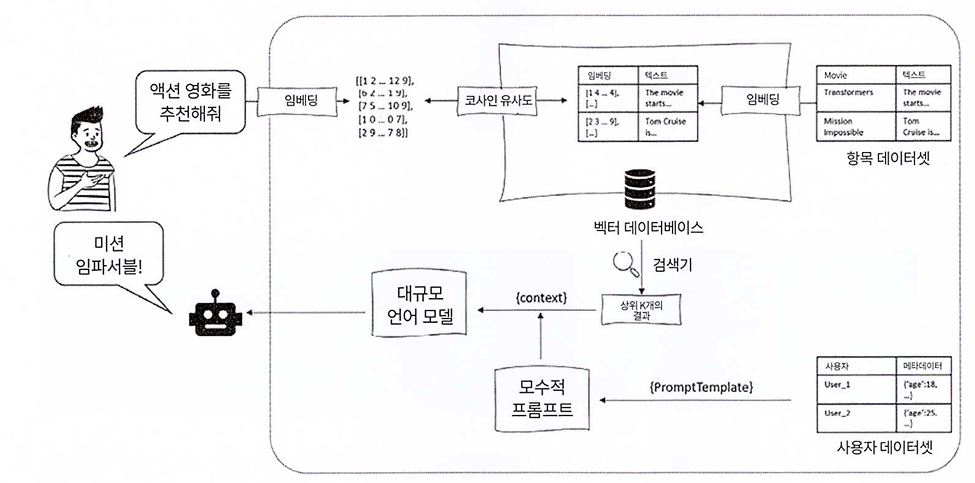

In [84]:
# 사용자의 선호도에 대한 약간의 정보 확보
# 사용자의 속성(이름, 나이, 성별), 영화에 대한 리뷰(평점 1~10점)가 포함된 데이터셋
data = {
    "username": ["Alice", "Bob"],
    "age": [25, 32],
    "gender": ["F", "M"],
    "movies": [
        [("Transformers: The Last Knight", 7), ("Pokémon: Spell of the Unknown", 5)],
        [("Bon Cop Bad Cop 2", 8), ("Goon: Last of the Enforcers", 9)]
    ]
}

# "movies" 열을 딕셔너리로 변환
for i, row_movies in enumerate(data["movies"]):
    movie_dict = {}
    for movie, rating in row_movies:
        movie_dict[movie] = rating
    data["movies"][i] = movie_dict

# 판다스 데이터프레임 생성
df = pd.DataFrame(data)

df.head()


,username,age,gender,movies
0,Alice,25,F,"{'Transformers: The Last Knight': 7, 'Pokémon:..."
1,Bob,32,M,"{'Bon Cop Bad Cop 2': 8, 'Goon: Last of the En..."


In [85]:
# 여기서 차이점은 사용자에게 변수 값을 제공하도록 요청하는 대신 사용자 데이터셋에서 직접 변수를 수집한다는 것0

template_prefix = """당신은 사용자의 취향에 맞는 영화를 찾아주는 **영화 추천 시스템**입니다.
아래에 제공된 문맥(context)을 참고하여 마지막에 제시된 질문에 답변하세요.
만약 답을 모른다면, 모른다고만 말하고 임의로 지어내거나 추측하지 마세요.

{context}"""

user_info = """다음은 사용자에 대한 정보입니다.
이 정보를 활용하여 추천 결과를 더 정확하게 조정할 수 있습니다:
나이: {age}
성별: {gender}
이미 시청한 영화 및 평점: {movies}"""

template_suffix = """질문: {question}
당신의 답변:"""


In [86]:
# user_info 청크 형식을 지정. 시스템과 상호 작용하는 사용자가  Alice라 가정
age = df.loc[df['username']=='Alice']['age'][0]
gender = df.loc[df['username']=='Alice']['gender'][0]

movies = ''
# 딕셔너리를 순회하여 영화 제목과 평점을 출력
for movie, rating in df['movies'][0].items():
    output_string = f"Movie: {movie}, Rating: {rating}" + "\n"
    movies+=output_string
    #print(output_string)
user_info = user_info.format(age = age, gender = gender, movies = movies)

COMBINED_PROMPT = template_prefix +'\n'+ user_info +'\n'+ template_suffix
print(COMBINED_PROMPT)

당신은 사용자의 취향에 맞는 영화를 찾아주는 **영화 추천 시스템**입니다.
아래에 제공된 문맥(context)을 참고하여 마지막에 제시된 질문에 답변하세요.
만약 답을 모른다면, 모른다고만 말하고 임의로 지어내거나 추측하지 마세요.

{context}
다음은 사용자에 대한 정보입니다.
이 정보를 활용하여 추천 결과를 더 정확하게 조정할 수 있습니다:
나이: 25
성별: F
이미 시청한 영화 및 평점: Movie: Transformers: The Last Knight, Rating: 7
Movie: Pokémon: Spell of the Unknown, Rating: 5

질문: {question}
당신의 답변:


In [90]:
PROMPT = PromptTemplate(
    template=COMBINED_PROMPT,
    input_variables=["context", "question"])

qa = build_retrieval_qa(
    llm=ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0.2,
        max_tokens=800),
    retriever=docsearch.as_retriever(),
    return_source_documents=True,
    prompt=PROMPT
    )

query = "Can you suggest me some action movie based on my background?"
result = qa({'query':query})
print(result['result'])

Based on your background and the movies you've rated, I recommend the following action movies:

1. **Hitman** - This film features a genetically engineered assassin who gets caught in a web of intrigue and betrayal. With its intense action and thrilling plot, it might appeal to your taste.

2. **xXx: Return of Xander Cage** - If you enjoy high-octane action and adventure, this movie about an extreme athlete turned government operative could be a great fit. It combines action with a conspiracy plot that keeps you on the edge of your seat.

Both of these films have a mix of action and thrilling elements that align with your interests. Enjoy watching!


In [91]:
result['source_documents']

[Document(metadata={}, page_content='Title: A Good Day to Die Hard. Overview: Iconoclastic, take-no-prisoners cop John McClane, finds himself for the first time on foreign soil after traveling to Moscow to help his wayward son Jack - unaware that Jack is really a highly-trained CIA operative out to stop a nuclear weapons heist. With the Russian underworld in pursuit, and battling a countdown to war, the two McClanes discover that their opposing methods make them unstoppable heroes. Genres: Action, Thriller. Rating: 5.178041993422717'),
 Document(metadata={}, page_content='Title: The Transporter Refueled. Overview: The fast-paced action movie is again set in the criminal underworld in France, where Frank Martin is known as The Transporter, because he is the best driver and mercenary money can buy. In this installment, he meets Anna and they attempt to take down a group of ruthless Russian human traffickers who also have kidnapped Frank’s father. Genres: Thriller, Action, Crime. Rating: 